<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula08a_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:,2:4]
y = data.target

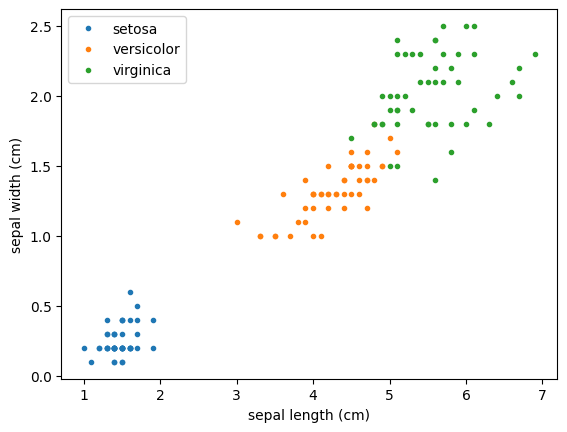

In [4]:
import matplotlib.pyplot as plt

def plot_dataset(X, y):
  for i in range(len(set(y))):
    plt.plot(X[y==i,0], X[y==i,1], '.', label=data.target_names[i])
  plt.xlabel(data.feature_names[0])
  plt.ylabel(data.feature_names[1])
  plt.legend()

plot_dataset(X, y)
plt.show()

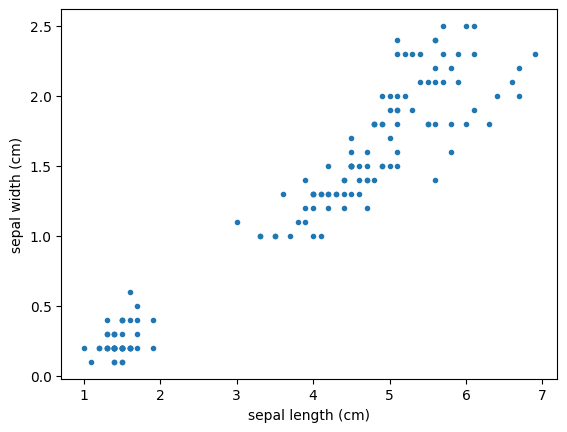

In [5]:
plt.scatter(X[:,0], X[:,1], marker='.')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.show()

[[5.59583333 2.0375    ]
 [4.26923077 1.34230769]
 [1.462      0.246     ]]
11


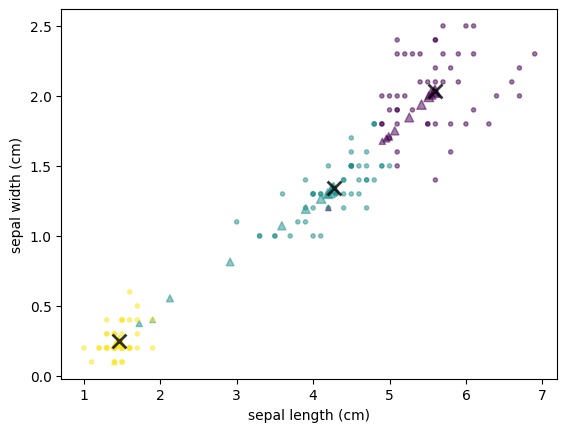

In [82]:
from sklearn.base import BaseEstimator, ClusterMixin, TransformerMixin
import numpy as np
import random

class KMeans(BaseEstimator, ClusterMixin, TransformerMixin):
  def __init__(self, n_clusters=3, max_iter=100):
    self.n_clusters = n_clusters
    self.max_iter = max_iter

  def fit(self, X, y=None):
    self.centroids = X[random.sample(range(len(X)), self.n_clusters)]
    self.previous_centroids = []
    self.previous_centroids.append(self.centroids.copy())
    max_iter = self.max_iter
    while max_iter > 0:
      max_iter -= 1
      y_pred = self.predict(X)
      for i in range(self.n_clusters):
        self.centroids[i] = np.mean(X[y_pred==i], axis=0)
      if np.allclose(self.centroids, self.previous_centroids[-1], atol=1e-9):
        break
      self.previous_centroids.append(self.centroids.copy())
    return self

  def distances(self, x):
    differences = self.centroids - x
    squared = differences ** 2
    summed = np.sum(squared, axis=1)
    root = np.sqrt(summed)
    return root

  def predict(self, X):
    y_pred = np.empty((X.shape[0],))
    for i in range(X.shape[0]):
      distances = self.distances(X[i])
      centroid_idx = np.argmin(distances)
      y_pred[i] = centroid_idx
    return y_pred

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
print(kmeans.centroids)
print(len(kmeans.previous_centroids))

y_pred = kmeans.predict(X)
for i in range(len(kmeans.previous_centroids)):
  prev_centr = kmeans.previous_centroids[i].copy()
  plt.scatter(prev_centr[:,0], prev_centr[:,1], c=list(set(y_pred)),
              marker='^', alpha=0.5, s=5*(i+3))
plt.scatter(X[:,0], X[:,1], c=y_pred, marker='.', alpha=0.5)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1],
            c='k', marker='x', s=100, linewidths=2, alpha=0.8)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.show()

In [83]:
def define_axes(X):
    offset = 0.1
    min1, max1 = X[:, 0].min(), X[:, 0].max()
    min2, max2 = X[:, 1].min(), X[:, 1].max()
    return [min1-offset, max1+offset, min2-offset, max2+offset]

def plot_predictions(clf, X):
    axes = define_axes(X)
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

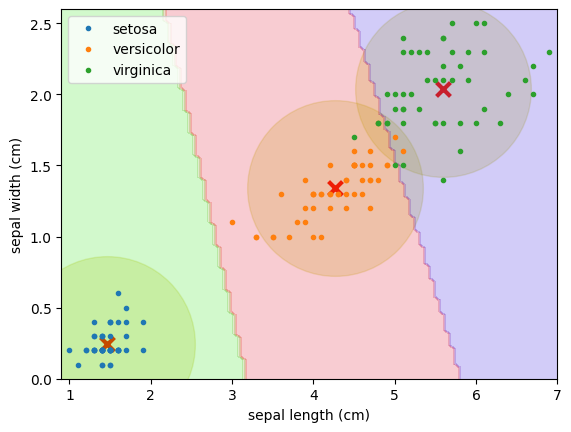

In [85]:
plot_dataset(X, y)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1],
            marker='x', color='r', s=100, linewidths=3)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1],
            marker='o', color='y', s=16000, linewidths=1, alpha=0.2)
plot_predictions(kmeans, X)
plt.show()